# Meteora DLMM Bin Atlas: connecting, fetching, normalizing, visualizing

Read-only research notebook for Meteora DLMM **bin-level liquidity**. No Solana node, no wallet, no transactions.

## Summary

| | |
|---|---|
| **Goal** | Build intuition for the DLMM bin lattice, then load one real pool snapshot and inspect how liquidity is distributed around the active bin. |
| **Unit of data** | One row per **price bin** — fixed price `P`, reserves `(x, y)`, liquidity `L`, and distance from the active bin. |
| **Data sources** | **Solana RPC** (`SOLANA_RPC_URL`) — JSON-RPC to a hosted node, same role as Infura/Alchemy on Ethereum; plus **Meteora datapi** for pool discovery and **`data/manual_pools.json`** fallback. See [RPC model](#rpc-model) below. |
| **Pipeline** | `make atlas` (single snapshot) or `make temporal` (OHLCV + snapshot series for animation) |
| **Outputs** | Raw JSON under `data/raw/`, normalized `bin_atlas_<pool>_<ts>.csv`, tables and plots in this notebook. |
| **Out of scope** | Swaps, LP deposits, wallets, trading, or live indexing — we only **read** chain state. |

## Notebook flow

1. **Setup** — env, RPC model
2. **Concepts** — `(P, L) ↔ (x, y)` coordinate embedding; swap book-walk; **how LPs refill shelves after trades**
3. **Fetch** — run TypeScript pipeline for one pool
4. **Explore** — load CSV, sanity checks, color-coded bin-structure table, liquidity plot

The conceptual sections use toy numbers; the fetch/explore sections use real on-chain data.

## Environment

In [1]:
import json

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from meteora_bin_atlas import (
    DATA_PROCESSED,
    DATA_RAW,
    PROJECT_ROOT,
    get_rpc_info,
    latest_matching,
    load_project_env,
)
from meteora_bin_atlas.concepts import (
    build_refill_steps_df,
    build_swap_steps_df,
    build_toy_embedding_df,
    plot_coordinate_embedding,
    plot_refill_loop,
    plot_swap_walk,
)
from meteora_bin_atlas.explore import (
    build_active_summary,
    parse_token_labels,
    plot_liquidity_by_bin,
    prepare_neighborhood,
    print_sanity_checks,
)
from meteora_bin_atlas.explore.tables import (
    build_bin_structure_df,
    style_bin_ladder,
    style_pattern_summary,
)
from meteora_bin_atlas.temporal import (
    load_bin_atlas_series,
    load_pool_ohlcv,
    summarize_bin_atlas_series,
)

load_project_env()
print(f"Project root: {PROJECT_ROOT}")


Project root: /Users/echow/Desktop/meteora_bin_atlas


## RPC model

**What is an RPC here?** Same idea as on Ethereum: your code sends HTTPS **JSON-RPC** requests to a remote Solana node. You are not running a node in this repo — you only *read* chain state (`getAccountInfo`, `getMultipleAccounts`, `getSlot`, …) through that URL. Our TypeScript pipeline and this notebook point at one URL in `SOLANA_RPC_URL`; no wallet, no transactions.

### Does Solana provide an RPC endpoint?

**Yes.** Solana operates **public RPC endpoints** for each cluster — for example `https://api.mainnet-beta.solana.com` (mainnet) and `https://api.devnet.solana.com` (devnet). They are free, require no API key, and are fine for smoke tests and light reads. They are **rate-limited** and not meant for heavy or production traffic (large bin-array fetches can hit limits quickly).

### How this compares to Infura / Chainstack / Alchemy

On Ethereum, Infura, Alchemy, and Chainstack are **hosted node providers**: they run the chain software for you and sell reliable RPC access over HTTPS with an API key.

Solana has the same **third-party hosted provider** layer — Helius, QuickNode, Triton, Alchemy, Chainstack, and others. Functionally they play the same role as Infura-style services:

| | Public Solana RPC | Hosted provider (Helius, QuickNode, …) | Own Solana node |
|---|---|---|---|
| **Who runs it** | Solana Foundation / public infra | Vendor | You |
| **Setup** | Paste the public URL | Sign up; put API key in URL | Provision server, install validator/RPC, sync |
| **Cost** | Free | Free tier → paid plans | Hardware, bandwidth, ops time |
| **Rate limits** | Strict, shared | Higher / custom quotas | None (your hardware is the limit) |
| **Best for** | Smoke tests, one-off reads | Pipelines, notebooks, apps | Indexers, trading infra, teams that already run validators |

For this project, a **private hosted RPC** (or a generous free tier) is the practical choice when fetching full bin arrays for a real pool. The public endpoint is enough to verify connectivity.

### Running your own node

You can also run a **Solana validator or dedicated RPC node** yourself. That gives full control and no vendor rate limits, but the ops burden is much higher than “spin up an Infura project”:

- Large RAM and fast NVMe storage to hold ledger state
- Ongoing software upgrades and monitoring
- Bandwidth and sync time, especially on mainnet

Most research and app workflows — including this atlas — use a **hosted RPC URL** instead of operating hardware.

### In this repo

Set `SOLANA_RPC_URL` in `.env` (see `.env.example`). Everything here is **read-only**. We print only the RPC **hostname** below, never the full URL (hosted URLs often embed secret API keys).

In [2]:
rpc = get_rpc_info()
print(f"RPC host: {rpc.host}")
print(f"Cluster: {rpc.cluster}")


RPC host: api.mainnet-beta.solana.com
Cluster: mainnet-beta


## Coordinate embedding: (P, L) and the pullback to (x, y)

Each DLMM bin is a **fixed-price shelf** on a discrete ladder. Two coordinate layers describe the same liquidity:

1. **Price–liquidity space** `(P, L)` — each bin index `i` maps to a price `P(i)`; the pool reports a liquidity scalar `L` for that shelf.
2. **Reserve space** `(x, y)` — the actual token inventories stored on-chain in that bin.

Meteora's per-bin binding ([DLMM formulas](https://docs.meteora.ag/core-products/dlmm/formulas.md)) ties them together:

```text
L = P · x + y
```

Read `P` as the bin's fixed price (here: USDC per SOL), with `x` in SOL and `y` in USDC. `L` is the bin's liquidity measured in **Y terms** at that price.

**Pullback along the embedding:** given `(P, L)` on a shelf, feasible reserves lie on the line `y = L − P·x` in `(x, y)` space. DLMM placement picks a corner of that line:

- **Bid bins** (`distance < 0`): `x = 0`, so `L = y` — shelf is Y-only (USDC waiting if price falls).
- **Ask bins** (`distance > 0`): `y = 0`, so `L = P·x` — shelf is X-only (SOL waiting if price rises).
- **Active bin** (`distance = 0`): often a mix of both as price sits on the handoff.

The table and diagram below use **illustrative units** (same structure as the real bin atlas loaded later).

,distance_from_active,side,P (USDC/SOL),x (SOL),y (USDC),L = P·x + y (USDC),"pullback (x,y)"
0,-1,Bid shelf,149.63,0.00,1800000.0,1.800000e+06,x=0 → y=L
1,0,Active shelf,150.00,1.68,1837912.0,1.838164e+06,mix on line y = L − P·x
2,1,Ask shelf,150.38,28824.88,0.0,4.334685e+06,y=0 → x=L/P


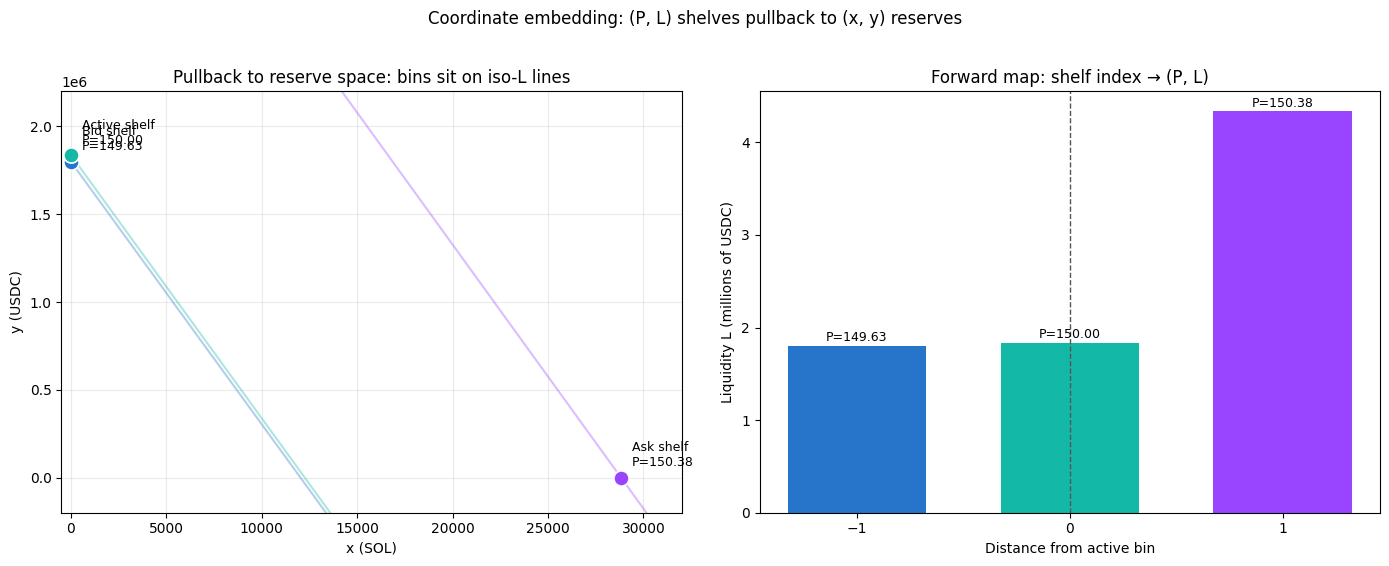

In [3]:
embedding_df = build_toy_embedding_df()
display(embedding_df)

fig = plot_coordinate_embedding(embedding_df)
plt.show()


## How a swap walks the bin book

Inside one bin, trades execute at that bin's **fixed price** (zero price impact within the shelf). When the active shelf can no longer satisfy the trade, the pool **shifts the active bin** one step on the ladder — that is the discrete price jump.

Example: trader **buys SOL** (pool sends X, receives Y). The swap:

1. Consumes SOL from the **active bin** at `P_active`, crediting USDC into the same bin.
2. If SOL on that shelf runs out, the active bin moves **up** (`distance + 1`) into the next ask shelf.
3. Repeats until the order is filled or liquidity runs out.

Selling SOL is the mirror: consume USDC from active / bid shelves and walk **down** the ladder.

### Where swap fees go (and how they relate to `x` / `y`)

Swap fees are **not** the same thing as the bin's trading reserves. Each bin carries two parallel ledgers:

| Ledger | On-chain fields (SDK) | What it is |
|---|---|---|
| **Trading reserves** | `xAmount`, `yAmount` | Inventory available for the next swap at this shelf's fixed price. This is what our `x_amount` / `y_amount` columns show. |
| **Fee accumulators** | `feeAmountXPerTokenStored`, `feeAmountYPerTokenStored` | Cumulative fee earned **per unit of liquidity share** in this bin, tracked separately in X and Y. |

When a swap crosses a bin, the program charges base + variable fee on that bin's fill, keeps a protocol slice (~10% on standard pools), and credits the LP slice to that bin's fee accumulators. Which side grows depends on the pool's **collect fee mode** (`InputOnly` = fee token is the swap's *input*; `OnlyY` = always token Y). For this SOL-USDC pool (`collectFeeMode = InputOnly`), a buy-SOL sweep accrues fees in USDC (`y`); a sell-SOL sweep accrues fees in SOL (`x`).

**LP positions** hold liquidity **shares** in specific bins. Each position remembers the last fee checkpoint it saw; claimable fee is roughly:

```text
your_liquidity_share × (bin's current fee-per-token − your last checkpoint)
```

summed over every bin in the position. Those claimable amounts are **balances owed to the LP in X and/or Y** — but they sit in the fee ledger, not in `xAmount`/`yAmount`. LPs collect them with a `claimSwapFee` transaction (fees do not auto-compound into trading reserves).

So: fees **do** correspond to token X and Y balances **for each LP position**, but they are **not** the pool-wide `x_amount`/`y_amount` reserves you see in the bin atlas plots. The atlas is trading microstructure; fee earnings are a per-position overlay on top.

### After the swap: how does the pool get filled again?

**Swaps redistribute trading reserves; they do not mint new liquidity.** When traders buy SOL, ask-side bins lose `x` and gain `y` from swap proceeds; shelves that were emptied of SOL stay that way until someone deposits again.

Refill comes from **LPs (liquidity providers)**, not from the swap engine:

| Mechanism | What happens |
|---|---|
| **Add liquidity** | An LP submits a deposit transaction targeting a **bin range** (and a shape: Spot, Curve, Bid-Ask). Tokens land on the chosen shelves — Y on bid bins, X on ask bins, mix near active — increasing `xAmount`/`yAmount`. |
| **Fees** | A separate slice of each crossed bin's fill accrues to `feeAmountX/YPerTokenStored` and is attributed to LP positions by share. Incentivizes deposits near active, but does not refill offering depth by itself. |
| **Reposition / remove** | LPs can widen, shift, or withdraw ranges as price moves — the lattice **deforms over time** as deposits and withdrawals land on-chain. |
| **No auto-refill** | The pool does not borrow or rebalance itself. Wrong-side or depleted **offering** depth (e.g. no SOL left to sell on ask shelves) stays that way until new `addLiquidity` or repositioning txs arrive. |

> **Note — walked shelves vs. fee residue.** When a trader buys SOL, ask shelves can reach **`x = 0`** — genuinely drained of the offering token. What remains in `y` is mostly **swap proceeds** (USDC paid in at fixed `P`), not fee dust and not leftover SOL. Fees are a smaller, separately tracked credit in the fee ledger; they do not explain why SOL remains on a shelf (it doesn't).

So the full loop is: **LPs seed shelves → traders swap (reserves reshuffle, fees accrue per position) → active bin walks → LPs add depth, claim fees, or reposition.** This notebook snapshots on-chain **trading reserves** only; it does not fetch position accounts or claimable fee balances.

The schematics below: (A) swap walk across shelves, (B) LP deposit restoring depleted ask depth.

**Shelf colors** (same key on both figures):

| Color | Meaning |
|---|---|
| Blue | USDC (Y) stocked on bid shelf |
| Purple | SOL (X) stocked on ask shelf |
| Green | Active shelf — current price / handoff |
| Grey | Depleted or empty shelf (e.g. SOL sold out after the swap) |

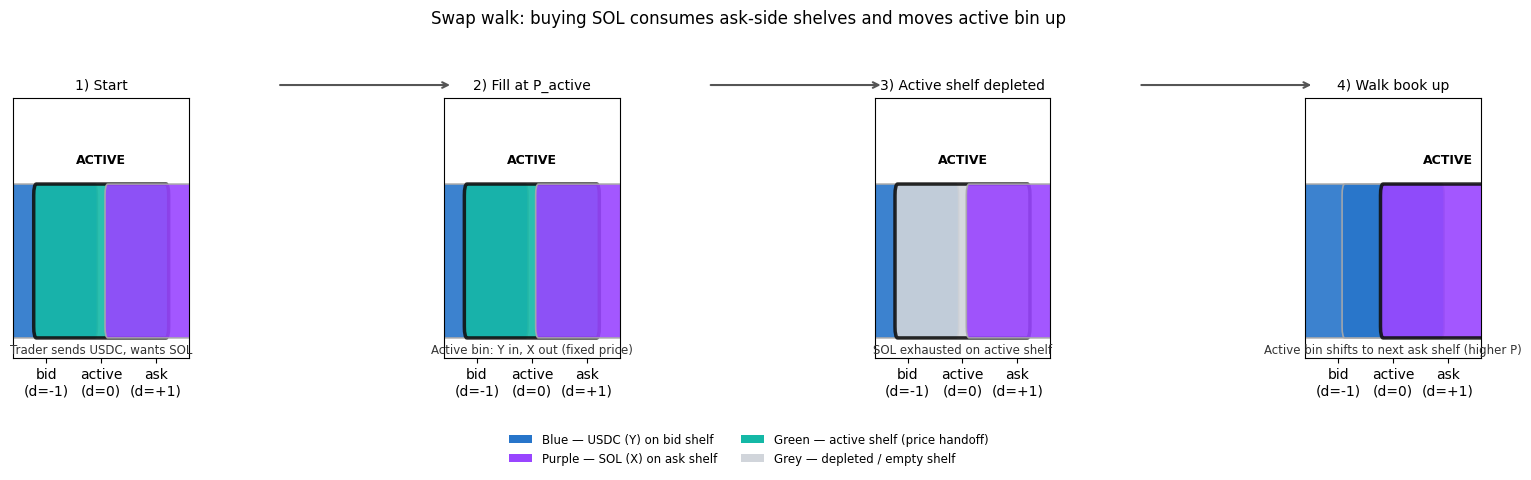

Swap walk (trader buys SOL):


,step,event,pool adjustment
0,1,Trader input,USDC (Y) arrives at active bin
1,2,Within-bin fill,SOL (X) leaves active bin at fixed P_active
2,3,Shelf empty,Active bin has no SOL left to sell
3,4,Book walk,active_bin_id += 1; next ask shelf becomes active
4,5,Repeat,Continue at higher price until order filled


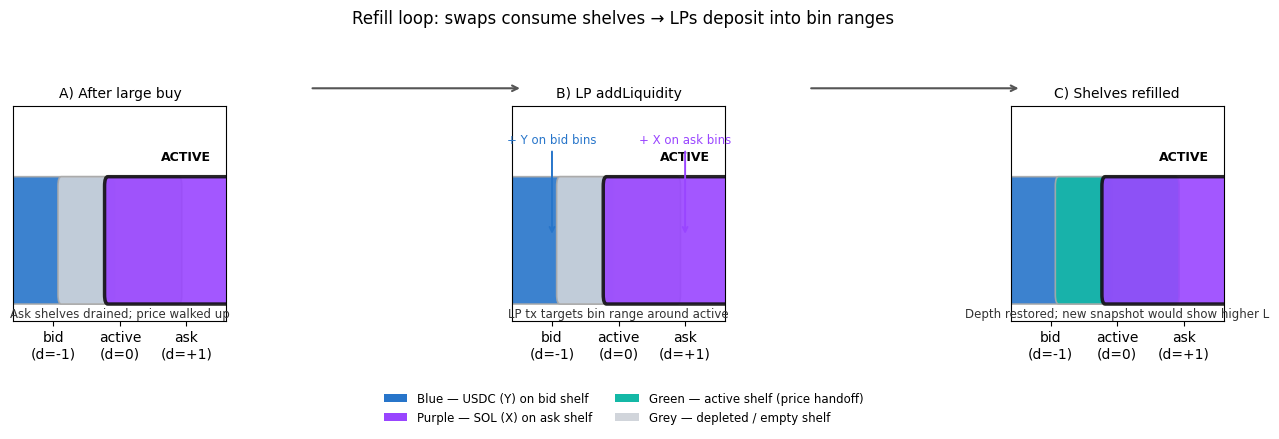


Refill loop (LP restores depth):


,step,event,who / what changes
0,1,Post-swap state,"Traded bins: offering token depleted, input to..."
1,2,LP deposit tx,"Wallet submits addLiquidity over [bin_min, bin..."
2,3,Token placement,"Y lands on bid shelves, X on ask shelves, mix ..."
3,4,On-chain update,bin.amountX / amountY / liquiditySupply increa...
4,5,Next snapshot,Our fetch pipeline reads the updated lattice (...


In [4]:
fig = plot_swap_walk()
plt.show()

print("Swap walk (trader buys SOL):")
display(build_swap_steps_df())

fig2 = plot_refill_loop()
plt.show()

print("\nRefill loop (LP restores depth):")
display(build_refill_steps_df())


## Fetch pool candidates

Run the TypeScript discovery script, then load the processed CSV.

In [5]:
!cd {PROJECT_ROOT} && npm run discover:pools



> meteora-bin-atlas@0.1.0 discover:pools
> tsx src/scripts/step1_discover_pools.ts

Discovery method: meteora_api
Candidate pools: 10
Raw output: /Users/echow/Desktop/meteora_bin_atlas/data/raw/pools_2026-06-07T06-34-01-113Z.json
Processed output: /Users/echow/Desktop/meteora_bin_atlas/data/processed/pool_candidates.csv
Warnings:
- Legacy Meteora API https://dlmm-api.meteora.ag/pair/all returned HTTP 404; using https://dlmm.datapi.meteora.ag/pools instead.
Pool discovery complete.
⠙

In [6]:
pool_candidates_path = DATA_PROCESSED / "pool_candidates.csv"
pool_candidates = pd.read_csv(pool_candidates_path)
pool_candidates.head()


,pool_address,token_x_mint,token_y_mint,bin_step,active_bin_id,raw_name_or_symbol_if_available,source,fetched_at_utc
0,5rCf1DM8LjKTw4YqhnoLcngyZYeNnQqztScTogYHAS6,So11111111111111111111111111111111111111112,EPjFWdd5AufqSSqeM2qN1xzybapC8G4wEGGkZwyTDt1v,4,-6844,SOL-USDC,meteora_api,2026-06-07T06:34:01.114Z
1,9p3aRWnbu5vAmHXvsToMGfwmbkTJSwGr5G5xxSxmkB8N,CWZ6BsdnjkDVTGkmL6bGbJXXig6ceef12KvyGQW14cMt,Es9vMFrzaCERmJfrF4H2FYD4KCoNkY11McCe8BenwNYB,80,-489,ANTFUN-USDT,meteora_api,2026-06-07T06:34:01.114Z
2,ANCx141SujgVdbKz9NTEH8F38qWsnyyXsVju64aU3qLB,98sMhvDwXj1RQi5c5Mndm3vPe9cBqPrbLaufMXFNMh5g,EPjFWdd5AufqSSqeM2qN1xzybapC8G4wEGGkZwyTDt1v,20,-1411,HYPE-USDC,meteora_api,2026-06-07T06:34:01.114Z
3,7ubS3GccjhQY99AYNKXjNJqnXjaokEdfdV915xnCb96r,cbbtcf3aa214zXHbiAZQwf4122FBYbraNdFqgw4iMij,EPjFWdd5AufqSSqeM2qN1xzybapC8G4wEGGkZwyTDt1v,4,16081,cbBTC-USDC,meteora_api,2026-06-07T06:34:01.114Z
4,HcCbiQqc55uHtP2MJu7BYdVPi9s4j45R4zXcwRmJgCXX,So11111111111111111111111111111111111111112,EPjFWdd5AufqSSqeM2qN1xzybapC8G4wEGGkZwyTDt1v,5,-5476,SOL-USDC,meteora_api,2026-06-07T06:34:01.114Z


## Choose one pool

Use the first discovered candidate, or set `POOL_ADDRESS` manually.

In [7]:
POOL_ADDRESS = pool_candidates.iloc[0]["pool_address"]
# POOL_ADDRESS = "5rCf1DM8LjKTw4YqhnoLcngyZYeNnQqztScTogYHAS6"

selected = pool_candidates[pool_candidates["pool_address"] == POOL_ADDRESS].iloc[0]
print(f"Pool: {POOL_ADDRESS}")
print(f"Label: {selected.get('raw_name_or_symbol_if_available', '')}")
print(f"Bin step: {selected.get('bin_step', '')}")


Pool: 5rCf1DM8LjKTw4YqhnoLcngyZYeNnQqztScTogYHAS6
Label: SOL-USDC
Bin step: 4


## Fetch pool snapshot

In [8]:
!cd {PROJECT_ROOT} && npm run fetch:pool -- --pool {POOL_ADDRESS}



> meteora-bin-atlas@0.1.0 fetch:pool
> tsx src/scripts/step2_fetch_pool_snapshot.ts --pool 5rCf1DM8LjKTw4YqhnoLcngyZYeNnQqztScTogYHAS6

Pool: 5rCf1DM8LjKTw4YqhnoLcngyZYeNnQqztScTogYHAS6
Active bin ID: -6844
Active bin price: 64.76094059474520433
Bin step: 4 bps
Token X mint: So11111111111111111111111111111111111111112
Token Y mint: EPjFWdd5AufqSSqeM2qN1xzybapC8G4wEGGkZwyTDt1v
Raw output: /Users/echow/Desktop/meteora_bin_atlas/data/raw/pool_snapshot_5rCf1DM8LjKTw4YqhnoLcngyZYeNnQqztScTogYHAS6_2026-06-07T06-34-03-353Z.json
Processed output: /Users/echow/Desktop/meteora_bin_atlas/data/processed/pool_snapshot_5rCf1DM8LjKTw4YqhnoLcngyZYeNnQqztScTogYHAS6_2026-06-07T06-34-03-353Z.json
Pool snapshot complete.
⠙

## Fetch bin arrays

In [9]:
!cd {PROJECT_ROOT} && npm run fetch:bins -- --pool {POOL_ADDRESS}



> meteora-bin-atlas@0.1.0 fetch:bins
> tsx src/scripts/step3_fetch_bin_arrays.ts --pool 5rCf1DM8LjKTw4YqhnoLcngyZYeNnQqztScTogYHAS6

Pool: 5rCf1DM8LjKTw4YqhnoLcngyZYeNnQqztScTogYHAS6
Method: getBinArrays
Bin arrays fetched: 195
Active bin ID: -6844
Raw output: /Users/echow/Desktop/meteora_bin_atlas/data/raw/bin_arrays_5rCf1DM8LjKTw4YqhnoLcngyZYeNnQqztScTogYHAS6_2026-06-07T06-34-04-443Z.json
Bin arrays fetch complete.
⠙

## Normalize bin atlas

In [10]:
!cd {PROJECT_ROOT} && npm run normalize:bins -- --pool {POOL_ADDRESS}



> meteora-bin-atlas@0.1.0 normalize:bins
> tsx src/scripts/step4_normalize_bin_atlas.ts --pool 5rCf1DM8LjKTw4YqhnoLcngyZYeNnQqztScTogYHAS6

Input: /Users/echow/Desktop/meteora_bin_atlas/data/raw/bin_arrays_5rCf1DM8LjKTw4YqhnoLcngyZYeNnQqztScTogYHAS6_2026-06-07T06-34-04-443Z.json
Method: getBinArrays
Bins normalized: 13650
Active bin rows: 1
Bins with non-zero liquidity: 4978
Active bin ID: -6844
Processed output: /Users/echow/Desktop/meteora_bin_atlas/data/processed/bin_atlas_5rCf1DM8LjKTw4YqhnoLcngyZYeNnQqztScTogYHAS6_2026-06-07T06-34-04-444Z.csv
Bin atlas normalization complete.
⠙

## Fetch temporal sample

For animation we need **many time slices** of the bin atlas. Meteora's datapi exposes **price/volume history** (OHLCV) but not historical bin-level liquidity — that only exists on-chain at fetch time.

| Source | Command | What you get |
|---|---|---|
| **All temporal data** | `make temporal` | OHLCV + live snapshot series + combined series CSV |
| **Price history only** | `make fetch-ohlcv` | Hourly/daily candles over days or weeks (no per-bin liquidity) |
| **Bin series only** | `make fetch-series` → `make normalize-series` | Repeated bounded bin fetches (~1 s RPC burst each) |

Public Solana RPC often rate-limits series collection (`fetch failed`). `make temporal` defaults to **10 snapshots** with **60s RPC backoff first**, then **30s interval** (~90s between snapshots, ~14 min total). Use a private `SOLANA_RPC_URL` to tighten `SERIES_RPC_BACKOFF_SEC` / `SERIES_INTERVAL_SEC`.

In [ ]:
# Conservative RPC backoff first, then interval; override for private RPC
OHLCV_TIMEFRAME = "1h"
OHLCV_LOOKBACK_DAYS = 7
SERIES_COUNT = 10
SERIES_RPC_BACKOFF_SEC = 60
SERIES_INTERVAL_SEC = 30

!cd {PROJECT_ROOT} && make temporal POOL={POOL_ADDRESS} \
  OHLCV_TIMEFRAME={OHLCV_TIMEFRAME} OHLCV_LOOKBACK_DAYS={OHLCV_LOOKBACK_DAYS} \
  SERIES_COUNT={SERIES_COUNT} SERIES_RPC_BACKOFF_SEC={SERIES_RPC_BACKOFF_SEC} \
  SERIES_INTERVAL_SEC={SERIES_INTERVAL_SEC}

## Load data

Single-snapshot bin atlas plus temporal artifacts from `make temporal` above.

In [ ]:
ohlcv_df, ohlcv_meta = load_pool_ohlcv(POOL_ADDRESS, timeframe=OHLCV_TIMEFRAME)
print(
    f"OHLCV: {ohlcv_meta['candle_count']} {ohlcv_meta['timeframe']} candles "
    f"({ohlcv_df['timestamp'].min()} → {ohlcv_df['timestamp'].max()})"
)
ohlcv_df.tail()

In [11]:
latest_bin_atlas_path = latest_matching(
    DATA_PROCESSED, f"bin_atlas_{POOL_ADDRESS}_*.csv"
)
df = pd.read_csv(latest_bin_atlas_path)
print(f"Loaded: {latest_bin_atlas_path.name}")
df.head()


Loaded: bin_atlas_5rCf1DM8LjKTw4YqhnoLcngyZYeNnQqztScTogYHAS6_2026-06-07T06-34-04-444Z.csv


,pool_address,fetched_at_utc,bin_array_index,bin_id,distance_from_active,price,price_per_token,liquidity,x_amount,y_amount,composition_y,is_active_bin,raw_bin_array_pubkey,raw_fields_json
0,5rCf1DM8LjKTw4YqhnoLcngyZYeNnQqztScTogYHAS6,2026-06-07T06:34:04.444Z,-456,-31920,-25076,52717705093411,NaN,0,0,0,NaN,False,HjCTcS967DCu7pzMf5SD2EoBs8q6HvjUa1qnRrXdcAD1,"{""amountX"":""0"",""amountY"":""0"",""price"":""52717705..."
1,5rCf1DM8LjKTw4YqhnoLcngyZYeNnQqztScTogYHAS6,2026-06-07T06:34:04.444Z,-456,-31919,-25075,52738792175449,NaN,0,0,0,NaN,False,HjCTcS967DCu7pzMf5SD2EoBs8q6HvjUa1qnRrXdcAD1,"{""amountX"":""0"",""amountY"":""0"",""price"":""52738792..."
2,5rCf1DM8LjKTw4YqhnoLcngyZYeNnQqztScTogYHAS6,2026-06-07T06:34:04.444Z,-456,-31918,-25074,52759887692319,NaN,0,0,0,NaN,False,HjCTcS967DCu7pzMf5SD2EoBs8q6HvjUa1qnRrXdcAD1,"{""amountX"":""0"",""amountY"":""0"",""price"":""52759887..."
3,5rCf1DM8LjKTw4YqhnoLcngyZYeNnQqztScTogYHAS6,2026-06-07T06:34:04.444Z,-456,-31917,-25073,52780991647396,NaN,0,0,0,NaN,False,HjCTcS967DCu7pzMf5SD2EoBs8q6HvjUa1qnRrXdcAD1,"{""amountX"":""0"",""amountY"":""0"",""price"":""52780991..."
4,5rCf1DM8LjKTw4YqhnoLcngyZYeNnQqztScTogYHAS6,2026-06-07T06:34:04.444Z,-456,-31916,-25072,52802104044055,NaN,0,0,0,NaN,False,HjCTcS967DCu7pzMf5SD2EoBs8q6HvjUa1qnRrXdcAD1,"{""amountX"":""0"",""amountY"":""0"",""price"":""52802104..."


In [ ]:
series_df, series_path = load_bin_atlas_series(POOL_ADDRESS)
series_summary = summarize_bin_atlas_series(series_df)

print(f"Series CSV: {series_path.name}")
print(f"Snapshots: {series_summary['snapshot_index'].nunique()} | Rows: {len(series_df)}")
display(series_summary)

series_df.head()

In [12]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 13650 entries, 0 to 13649
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   pool_address          13650 non-null  str    
 1   fetched_at_utc        13650 non-null  str    
 2   bin_array_index       13650 non-null  int64  
 3   bin_id                13650 non-null  int64  
 4   distance_from_active  13650 non-null  int64  
 5   price                 13650 non-null  object 
 6   price_per_token       0 non-null      float64
 7   liquidity             13650 non-null  object 
 8   x_amount              13650 non-null  int64  
 9   y_amount              13650 non-null  int64  
 10  composition_y         4978 non-null   float64
 11  is_active_bin         13650 non-null  bool   
 12  raw_bin_array_pubkey  13650 non-null  str    
 13  raw_fields_json       13650 non-null  str    
dtypes: bool(1), float64(2), int64(5), object(2), str(4)
memory usage: 8.3+ MB


## Basic sanity checks

In [13]:
print_sanity_checks(df)

ZOOM_BINS = 30
neighborhood_df = prepare_neighborhood(df, zoom_bins=ZOOM_BINS)


bin_id range: -31920 30379
distance_from_active range: -25076 37223
active bin rows: 1

Neighborhood rows (±30 bins): 61


## DLMM side structure (why X and Y split around the active bin)

In a DLMM pool, liquidity is **not** symmetric around the active bin:

- **Bins below** the active bin (`distance_from_active < 0`) hold **token Y** (here: USDC). These are the bid side — liquidity waiting if price moves down.
- **Bins above** the active bin (`distance_from_active > 0`) hold **token X** (here: SOL). These are the ask side — liquidity waiting if price moves up.
- The **active bin** is the handoff: it typically holds a small mix of both as price sits on the boundary.

So it is normal to see **no Y on the ask side** and **no X on the bid side**. The data is not missing; that is how the lattice is laid out.

The **table below** lists ±10 bins around the active row (21 rows) with side, what is stocked, and each bin's role. Rows are **color-coded by token**: blue = Y (USDC), purple = X (SOL), teal = both at the active bin. The **liquidity plot after that** zooms wider (±`ZOOM_BINS`) with the same colors.

In [14]:
POOL_LABEL = selected.get("raw_name_or_symbol_if_available", POOL_ADDRESS)
tokens = parse_token_labels(POOL_LABEL, POOL_ADDRESS)
TOKEN_X, TOKEN_Y = tokens.token_x, tokens.token_y

bin_structure_df = build_bin_structure_df(neighborhood_df, TOKEN_X, TOKEN_Y)

TABLE_BINS = 10
table_df = bin_structure_df[
    bin_structure_df["distance_from_active"].between(-TABLE_BINS, TABLE_BINS)
].sort_values("distance_from_active")

print(f"Pool: {POOL_LABEL} ({POOL_ADDRESS})")
print(f"Active bin rows in zoom window: {bin_structure_df['is_active_bin'].sum()}\n")

summary = (
    table_df.groupby(["side", "stocked"], dropna=False)
    .size()
    .reset_index(name="bin_count")
    .sort_values(["side", "stocked"])
)

print("Pattern summary (should be Y-only on bid, X-only on ask, mix at active):")
display(style_pattern_summary(summary, TOKEN_X, TOKEN_Y))

print(f"\nBin ladder (±{TABLE_BINS} around active):")
display(style_bin_ladder(table_df, TOKEN_X, TOKEN_Y))


Pool: SOL-USDC (5rCf1DM8LjKTw4YqhnoLcngyZYeNnQqztScTogYHAS6)
Active bin rows in zoom window: 1

Pattern summary (should be Y-only on bid, X-only on ask, mix at active):


,side,stocked,bin_count
0,Active,X + Y (SOL + USDC),1
1,Ask (above active),X only (SOL),10
2,Bid (below active),Y only (USDC),10



Bin ladder (±10 around active):


,distance_from_active,bin_id,side,stocked,role,x_amount,y_amount
1336,-10,-6854,Bid (below active),Y only (USDC),Pool pays USDC if price drops to this shelf,0,2546019312
1337,-9,-6853,Bid (below active),Y only (USDC),Pool pays USDC if price drops to this shelf,0,2543494293
1338,-8,-6852,Bid (below active),Y only (USDC),Pool pays USDC if price drops to this shelf,0,2551609098
1339,-7,-6851,Bid (below active),Y only (USDC),Pool pays USDC if price drops to this shelf,0,2565567629
1340,-6,-6850,Bid (below active),Y only (USDC),Pool pays USDC if price drops to this shelf,0,2579204105
1341,-5,-6849,Bid (below active),Y only (USDC),Pool pays USDC if price drops to this shelf,0,2582744574
1342,-4,-6848,Bid (below active),Y only (USDC),Pool pays USDC if price drops to this shelf,0,2598700572
1343,-3,-6847,Bid (below active),Y only (USDC),Pool pays USDC if price drops to this shelf,0,2615627915
1344,-2,-6846,Bid (below active),Y only (USDC),Pool pays USDC if price drops to this shelf,0,5560100615
1345,-1,-6845,Bid (below active),Y only (USDC),Pool pays USDC if price drops to this shelf,0,5577246683


## Visualize liquidity by bin

Zoomed to ±`ZOOM_BINS` around the active bin. Compare with the table above: bid shelves below, ask shelves above.

In [15]:
pool_snapshot_path = latest_matching(
    DATA_PROCESSED, f"pool_snapshot_{POOL_ADDRESS}_*.json"
)
with pool_snapshot_path.open() as f:
    pool_snapshot = json.load(f)

active_mask = df["is_active_bin"].astype(str).str.lower().eq("true")
active_bin = df.loc[active_mask].iloc[0]
bin_step = pool_snapshot.get("bin_step", selected.get("bin_step"))

active_summary = build_active_summary(
    POOL_ADDRESS,
    POOL_LABEL,
    pool_snapshot,
    active_bin,
    TOKEN_X,
    TOKEN_Y,
    bin_step,
)

print("Active bin snapshot")
display(active_summary)


Active bin snapshot


,value,explanation
field,,
pool_address,5rCf1DM8LjKTw4YqhnoLcngyZYeNnQqztScTogYHAS6,Solana pubkey of this DLMM pool account.
pool_label,SOL-USDC,Human-readable pair label from Meteora discovery.
token_x_mint,So11111111111111111111111111111111111111112,Mint pubkey for token X (SOL); ask-side shelve...
token_y_mint,EPjFWdd5AufqSSqeM2qN1xzybapC8G4wEGGkZwyTDt1v,Mint pubkey for token Y (USDC); bid-side shelv...
bin_step_bps,4,Basis-point spacing between adjacent bin price...
active_bin_id,-6844,Global bin coordinate where price sits now (th...
bin_array_index,-98,Which on-chain bin-array account stores this s...
distance_from_active,0,Offset from the active shelf; always 0 on this...
price (USDC per SOL),64.76094059474520433,Human-readable fixed trade price at this shelf...


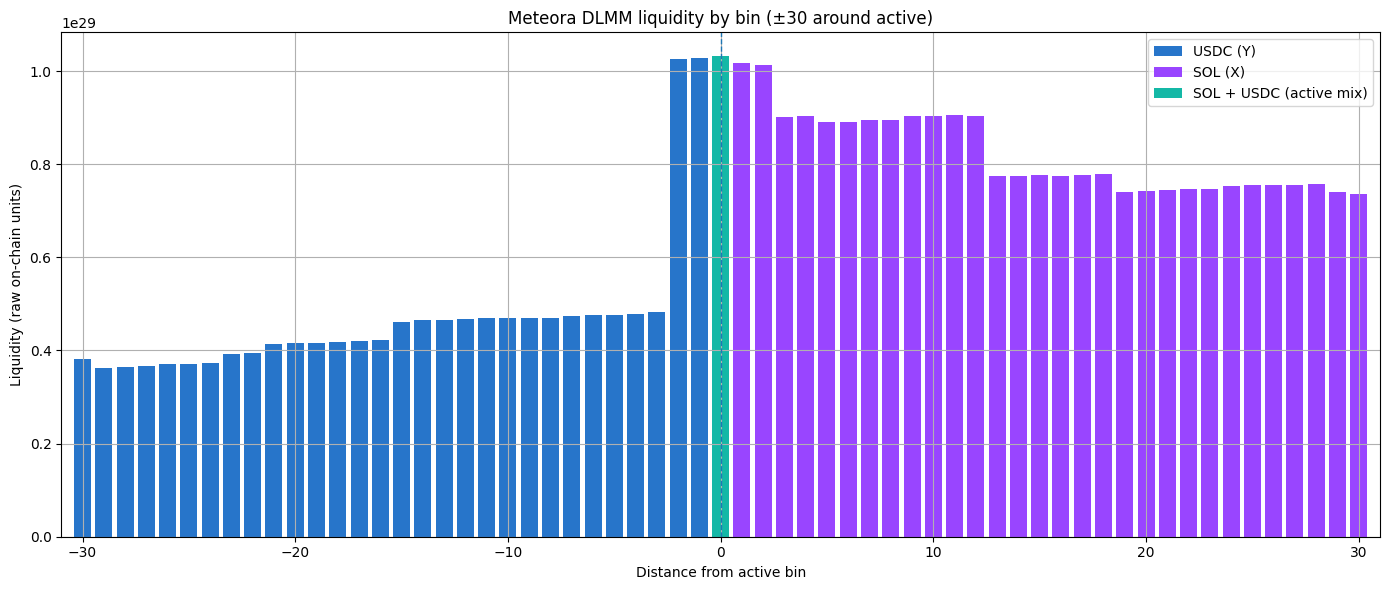

In [16]:
fig = plot_liquidity_by_bin(neighborhood_df, TOKEN_X, TOKEN_Y, zoom_bins=ZOOM_BINS)
plt.show()


## Microstructure notes

The active bin functions as a local coordinate center. Liquidity away from the active bin is a discrete field over price bins. A single snapshot gives the static shape; repeated snapshots would show migration and deformation.

## Next questions

- How concentrated is liquidity around the active bin?
- How asymmetric is liquidity on either side?
- How does the active bin move over time?
- Do volatile pools show wider liquidity distributions?
- How do stable pools differ from memecoin or SOL pairs?